# GBM-Finite-MC Comparison

## Monte Carlo vs GBM Finite Analytical Strategy

This notebook compares two withdrawal rate strategies over a **30-year retirement horizon**:
1. **MC Strategy**: Monte Carlo simulation with 30-year finite time horizon
2. **GBM Finite Analytical**: Closed-form analytical solution using spectral decomposition

We validate both approaches and visualize their behavior across different withdrawal rates.
The analytical solution should show minimal noise compared to MC simulations.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import gammaincc

# Import FIREworks strategies
from fireworks.strategies import MCStrategy, GBMFiniteAnalyticStrategy
from fireworks.strategies.mc_strategy import (
    MarketEnvironmentFactory,
    ConsumptionModelFactory,
)

print("Imports successful!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

Imports successful!
NumPy version: 2.3.5
Pandas version: 2.3.3


In [6]:
# Define market parameters (identical for both strategies)
MU = 0.07  # 7% annual return
VOLATILITY = 0.18  # 18% volatility
VARIANCE = VOLATILITY ** 2  # 0.0324
INITIAL_CAPITAL = 1_000_000  # $1M starting portfolio
TIME_HORIZON = 30  # 30-year retirement

# Create market environment and consumption models
market_env = MarketEnvironmentFactory.constant(MU, VARIANCE)
withdrawal_model = ConsumptionModelFactory.constant(40000)  # $40k/year initially

# Initialize strategies
mc_strategy = MCStrategy(
    market_environment=market_env,
    consumption_model=withdrawal_model,
    num_simulations=10000,
    num_steps=100
)

gbm_finite_strategy = GBMFiniteAnalyticStrategy(
    market_environment=market_env,
    consumption_model=withdrawal_model
)

print(f"Market Parameters:")
print(f"  Mean Return (μ): {MU:.1%}")
print(f"  Volatility (σ): {VOLATILITY:.1%}")
print(f"  Variance (σ²): {VARIANCE:.6f}")
print(f"\nRetirement Horizon: {TIME_HORIZON} years")
print(f"Initial Portfolio: ${INITIAL_CAPITAL:,.0f}")
print(f"Initial Withdrawal: $40,000 (4% rule)")

Market Parameters:
  Mean Return (μ): 7.0%
  Volatility (σ): 18.0%
  Variance (σ²): 0.032400

Retirement Horizon: 30 years
Initial Portfolio: $1,000,000
Initial Withdrawal: $40,000 (4% rule)


In [ ]:
# Withdrawal rate grid: 0.5% to 10% in 0.5% increments (centered on 4% rule)
withdrawal_rates = np.arange(0.005, 0.105, 0.005)
num_rates = len(withdrawal_rates)

# Storage
mc_ruin_probs = np.zeros(num_rates)
gbm_ruin_probs = np.zeros(num_rates)

print(f"Withdrawal Rate Grid:")
print(f"  Range: {withdrawal_rates.min():.2%} to {withdrawal_rates.max():.2%}")
print(f"  Increment: 0.5%")
print(f"  Total points: {num_rates}")
print(f"\nComputing sensitivity grid ({TIME_HORIZON}-year horizons)...")

for idx, rate in enumerate(withdrawal_rates):
    withdrawal = INITIAL_CAPITAL * rate
    
    # MC Strategy (10k simulations for clean curves)
    mc_result = mc_strategy.simulate(
        initial_capital=INITIAL_CAPITAL,
        annual_withdrawal=withdrawal,
        years=TIME_HORIZON,
        num_simulations=10000,
        num_steps=12*TIME_HORIZON  # monthly steps
    )
    mc_ruin_probs[idx] = mc_result['ruin_probability']
    
    # GBM Finite Analytical
    gbm_result = gbm_finite_strategy.simulate(
        initial_capital=INITIAL_CAPITAL,
        annual_withdrawal=withdrawal,
        years=TIME_HORIZON
    )
    gbm_ruin_probs[idx] = gbm_result['ruin_probability']
    
    print(f"  [{idx+1:2d}/{num_rates}] WR {rate:.1%}: MC {mc_ruin_probs[idx]:6.1%} | Analytical {gbm_ruin_probs[idx]:6.1%} (diff: {abs(gbm_ruin_probs[idx] - mc_ruin_probs[idx])*100:5.2f}%)")

print(f"\n✓ Grid computation complete!")

Withdrawal Rate Grid:
  Range: 0.50% to 10.00%
  Increment: 0.5%
  Total points: 20

Computing sensitivity grid (30-year horizons)...
  [ 1/20] WR 0.5%: MC   0.0% | Analytical   0.1% (diff:  0.14%)


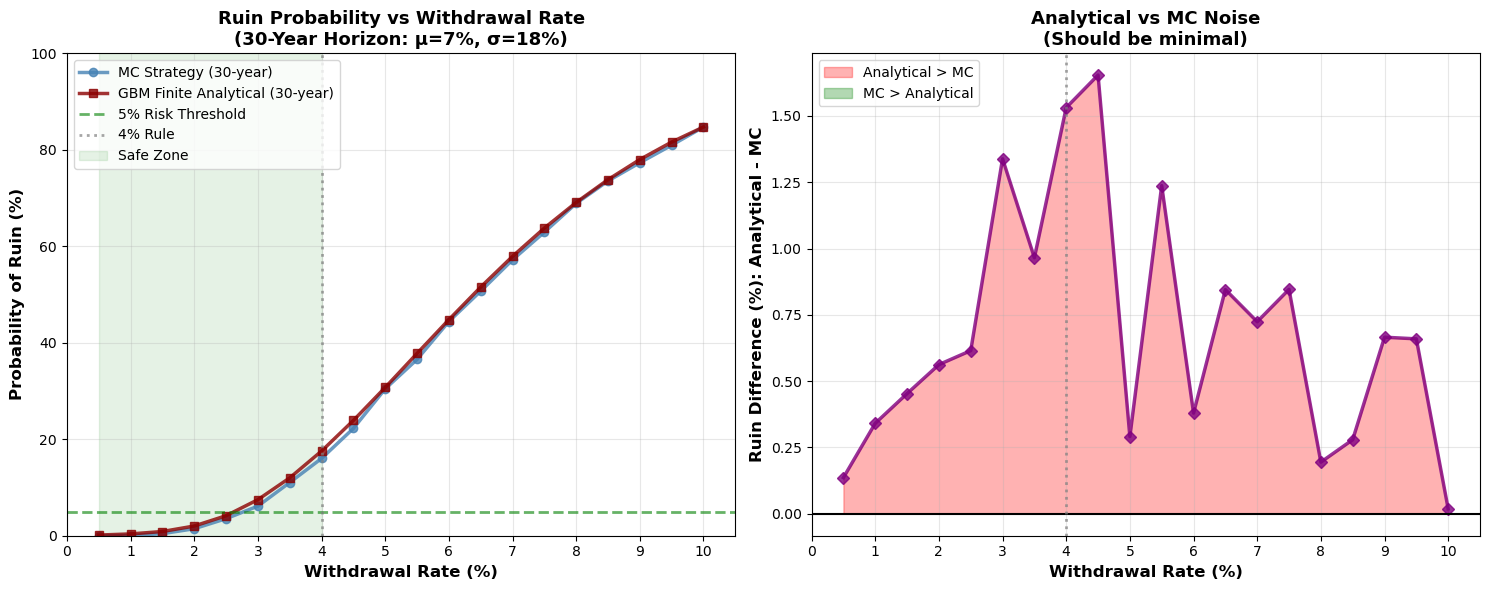


COMPARISON STATISTICS (30-Year Horizon)
Mean Absolute Difference: 0.687%
Max Absolute Difference: 1.654%
Std Dev of Difference: 0.453%

At 4% rule (WR=4%):
  MC Ruin Probability: 0.1601 (16.01%)
  Analytical Ruin Probability: 0.1754 (17.54%)
  Difference: 1.531%


In [4]:
# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Both strategies
ax1 = axes[0]
ax1.plot(withdrawal_rates * 100, mc_ruin_probs * 100, 'o-', linewidth=2.5, markersize=6, 
         label=f'MC Strategy ({TIME_HORIZON}-year)', color='steelblue', alpha=0.8)
ax1.plot(withdrawal_rates * 100, gbm_ruin_probs * 100, 's-', linewidth=2.5, markersize=6,
         label=f'GBM Finite Analytical ({TIME_HORIZON}-year)', color='darkred', alpha=0.8)
ax1.axhline(y=5, color='green', linestyle='--', linewidth=2, alpha=0.6, label='5% Risk Threshold')
ax1.axvline(x=4, color='gray', linestyle=':', linewidth=2, alpha=0.7, label='4% Rule')
ax1.fill_between(withdrawal_rates * 100, 0, 100, where=(withdrawal_rates <= 0.04), 
                  alpha=0.1, color='green', label='Safe Zone')
ax1.set_xlabel('Withdrawal Rate (%)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Probability of Ruin (%)', fontsize=12, fontweight='bold')
ax1.set_title(f'Ruin Probability vs Withdrawal Rate\n({TIME_HORIZON}-Year Horizon: μ=7%, σ=18%)', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left', fontsize=10)
ax1.set_ylim([0, 100])
ax1.set_xlim([0, 10.5])
ax1.set_xticks(np.arange(0, 11, 1))

# Plot 2: Difference (Analytical - MC) - should be very small noise
ax2 = axes[1]
difference = (gbm_ruin_probs - mc_ruin_probs) * 100
ax2.plot(withdrawal_rates * 100, difference, 'D-', linewidth=2.5, markersize=6, color='purple', alpha=0.8)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1.5)
ax2.axvline(x=4, color='gray', linestyle=':', linewidth=2, alpha=0.7)
ax2.fill_between(withdrawal_rates * 100, 0, difference, where=(difference >= 0), 
                  alpha=0.3, color='red', label='Analytical > MC')
ax2.fill_between(withdrawal_rates * 100, 0, difference, where=(difference < 0), 
                  alpha=0.3, color='green', label='MC > Analytical')
ax2.set_xlabel('Withdrawal Rate (%)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Ruin Difference (%): Analytical - MC', fontsize=12, fontweight='bold')
ax2.set_title(f'Analytical vs MC Noise\n(Should be minimal)', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper left', fontsize=10)
ax2.set_xlim([0, 10.5])
ax2.set_xticks(np.arange(0, 11, 1))

plt.tight_layout()
plt.show()

# Statistics
print(f"\n{'='*60}")
print(f"COMPARISON STATISTICS ({TIME_HORIZON}-Year Horizon)")
print(f"{'='*60}")
print(f"Mean Absolute Difference: {np.abs(difference).mean():.3f}%")
print(f"Max Absolute Difference: {np.abs(difference).max():.3f}%")
print(f"Std Dev of Difference: {difference.std():.3f}%")
print(f"\nAt 4% rule (WR=4%):")
idx_4pct = np.argmin(np.abs(withdrawal_rates - 0.04))
print(f"  MC Ruin Probability: {mc_ruin_probs[idx_4pct]:.4f} ({mc_ruin_probs[idx_4pct]*100:.2f}%)")
print(f"  Analytical Ruin Probability: {gbm_ruin_probs[idx_4pct]:.4f} ({gbm_ruin_probs[idx_4pct]*100:.2f}%)")
print(f"  Difference: {(gbm_ruin_probs[idx_4pct] - mc_ruin_probs[idx_4pct])*100:.3f}%")